# NIFTY50 Alpha#1 Guided Research — corrected signal orientation workflow

This notebook studies **Alpha#1** from *101 Formulaic Alphas* on the NIFTY50 universe.

The key improvement in this version:

> We do **not** assume that a high raw Alpha#1 score is bullish.

Instead, we first measure whether the raw signal is positively or negatively related to forward returns, then create an **oriented tradable signal**:

```text
if raw Alpha#1 has positive predictive relation:
    tradable_signal = raw_alpha001
else:
    tradable_signal = -raw_alpha001
```

This matters because in the first run the raw Alpha#1 appeared inverted for the current NIFTY50 sample.

## 1. Alpha#1 formula

```text
Alpha#1 =
rank(
    ts_argmax(
        signedpower(
            ((returns < 0) ? stddev(returns, 20) : close),
            2
        ),
        5
    )
) - 0.5
```

Where:

- `returns`: close-to-close return
- `stddev(returns, 20)`: 20-day rolling volatility
- `signedpower(x, 2)`: sign-preserving square
- `ts_argmax(x, 5)`: location of the maximum value in the last 5 days
- `rank(...)`: cross-sectional percentile rank across all stocks on the same date

Important:

- This is a **cross-sectional alpha**.
- It must be calculated across the universe, not one stock at a time.
- The raw formula does not guarantee that high score means buy in every market/universe.

## 2. Research questions

This notebook answers:

1. Can we calculate Alpha#1 cleanly for NIFTY50 stocks?
2. Is the raw signal positive or inverted on this sample?
3. Which horizon works best: 1d, 3d, 5d, or 10d?
4. Do top-ranked stocks outperform bottom-ranked stocks after orientation?
5. Which stocks are most compatible with the alpha?
6. Which regimes help or hurt?
7. What would today's candidate table look like?

In [1]:
from __future__ import annotations

import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError(
        "Install dependencies first: pip install yfinance pandas numpy matplotlib"
    ) from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Environment ready")

Environment ready


In [2]:
# Configuration

START_DATE = "2018-01-01"
END_DATE = None

FORWARD_HORIZONS = [1, 3, 5, 10]
DEFAULT_HORIZON = 5

TOP_N_VALUES = [5, 10]
ROUND_TRIP_COST_BPS = 10.0

# Use adjusted close for returns and as the price input for this research notebook.
# Reason: yfinance raw close can create corporate-action distortions.
# Later, the production data layer should own adjustment policy explicitly.
USE_ADJUSTED_PRICE_FOR_ALPHA = True

OUTPUT_DIR = Path("research/artifacts/alpha001_nifty50")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NIFTY50_SYMBOLS = [
    "ADANIENT", "ADANIPORTS", "APOLLOHOSP", "ASIANPAINT", "AXISBANK",
    "BAJAJ-AUTO", "BAJFINANCE", "BAJAJFINSV", "BEL", "BHARTIARTL",
    "CIPLA", "COALINDIA", "DRREDDY", "EICHERMOT", "ETERNAL",
    "GRASIM", "HCLTECH", "HDFCBANK", "HDFCLIFE", "HINDALCO",
    "HINDUNILVR", "ICICIBANK", "INDIGO", "INFY", "ITC",
    "JIOFIN", "JSWSTEEL", "KOTAKBANK", "LT", "M&M",
    "MARUTI", "MAXHEALTH", "NESTLEIND", "NTPC", "ONGC",
    "POWERGRID", "RELIANCE", "SBILIFE", "SHRIRAMFIN", "SBIN",
    "SUNPHARMA", "TATACONSUM", "TATAMOTORS", "TATASTEEL", "TCS",
    "TECHM", "TITAN", "TRENT", "ULTRACEMCO", "WIPRO"
]

YF_TICKERS = [f"{symbol}.NS" for symbol in NIFTY50_SYMBOLS]
SYMBOL_FROM_TICKER = dict(zip(YF_TICKERS, NIFTY50_SYMBOLS))
NIFTY_INDEX_TICKER = "^NSEI"

assert len(NIFTY50_SYMBOLS) == 50, f"Expected 50 symbols, got {len(NIFTY50_SYMBOLS)}"
assert len(set(NIFTY50_SYMBOLS)) == len(NIFTY50_SYMBOLS), "Duplicate symbols in universe"
print(f"Universe size: {len(NIFTY50_SYMBOLS)}")
print(f"Output dir: {OUTPUT_DIR}")

Universe size: 50
Output dir: research/artifacts/alpha001_nifty50


## 3. Download data

This notebook uses `yfinance` for rapid research. For production, this should move to your canonical MFT data pipeline and dataset snapshots.

Data-quality warning:

- current NIFTY50 membership causes survivorship bias,
- Yahoo data can have missing rows,
- symbol history can be shorter for recent constituents,
- corporate-action adjustment policy must be made explicit before promotion.

In [3]:
def download_yf_panel(tickers: list[str], start: str, end: str | None = None) -> pd.DataFrame:
    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=False,
    )
    if data.empty:
        raise ValueError("No data downloaded from yfinance.")
    return data


raw = download_yf_panel(YF_TICKERS, START_DATE, END_DATE)
raw.head()

/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future versio

Ticker     BAJAJ-AUTO.NS                                                              SBILIFE.NS                                                               TCS.NS  \
Price               Open         High          Low        Close    Adj Close  Volume        Open        High         Low       Close   Adj Close  Volume         Open   
Date                                                                                                                                                                    
2018-01-01        3340.0  3345.050049  3276.399902  3289.250000  2638.269043  174560  694.000000  703.000000  694.000000  699.500000  686.757507  174646  1341.150024   
2018-01-02        3309.0  3348.000000  3280.000000  3294.750000  2642.680908  297721  699.500000  700.150024  680.099976  685.099976  672.619751  342012  1330.000000   
2018-01-03        3310.0  3310.199951  3231.550049  3241.050049  2599.608887  372267  685.049988  695.000000  680.250000  690.500000  677.921448  125483  1316.000000   
2018-01-04        3244.0  3274.250000  3219.000000  3264.449951  2618.377686  256909  694.599976  702.200012  690.000000  701.599976  688.819214  411800  1325.000000   
2018-01-05        3263.0  3294.000000  3244.050049  3279.850098  2630.729492  113508  700.000000  704.900024  699.000000  701.950012  689.162842  195946  1325.000000   

Ticker                                                                  COALINDIA.NS                                                          SUNPHARMA.NS              \
Price              High          Low        Close    Adj Close   Volume         Open        High         Low       Close   Adj Close   Volume         Open        High   
Date                                                                                                                                                                     
2018-01-01  1347.400024  1317.500000  1322.800049  1083.771484  1351760   263.000000  267.299988  262.600006  266.649994  131.349823  3079260        571.5  585.400024   
2018-01-02  1334.800049  1310.099976  1315.599976  1077.872803  1920290   268.000000  270.899994  267.000000  270.049988  133.024628  5659389        577.0  582.000000   
2018-01-03  1334.500000  1315.599976  1319.324951  1080.924194  1257120   271.000000  273.450012  269.700012  271.850006  133.911316  9240120        575.0  578.950012   
2018-01-04  1331.000000  1320.000000  1328.550049  1088.482544   913082   272.899994  279.850006  272.200012  277.799988  136.842239  6919578        572.0  583.950012   
2018-01-05  1349.750000  1325.000000  1344.599976  1101.632568  1153706   278.500000  280.649994  278.000000  278.750000  137.310226  3344950        585.0  587.349976   

Ticker                                                  JSWSTEEL.NS                                                          HINDUNILVR.NS                                         \
Price              Low       Close   Adj Close   Volume        Open        High         Low       Close   Adj Close   Volume          Open         High          Low        Close   
Date                                                                                                                                                                                
2018-01-01  571.250000  574.049988  531.673340  5314142  269.500000  271.700012  264.350006  265.799988  242.621262  1261616   1367.000000  1367.000000  1340.050049  1344.500000   
2018-01-02  567.200012  572.150024  529.913452  3839130  267.000000  268.000000  261.700012  264.549988  241.480270  2277139   1345.000000  1349.800049  1328.550049  1338.599976   
2018-01-03  567.000000  569.049988  527.042297  2182632  267.850006  272.250000  266.350006  268.700012  245.268372  3279293   1344.699951  1356.800049  1335.000000  1350.349976   
2018-01-04  560.099976  581.200012  538.295471  6246746  270.750000  281.899994  269.500000  277.149994  252.981445  6281682   1350.099976  1356.150024  1341.449951  1352.250000   
2018-01-05  575.299

In [4]:
def extract_field(raw_data: pd.DataFrame, field: str) -> pd.DataFrame:
    frames = {}
    for ticker in YF_TICKERS:
        symbol = SYMBOL_FROM_TICKER[ticker]
        try:
            frames[symbol] = raw_data[(ticker, field)]
        except KeyError:
            continue
    return pd.DataFrame(frames).sort_index()


open_px_raw = extract_field(raw, "Open")
high_px_raw = extract_field(raw, "High")
low_px_raw = extract_field(raw, "Low")
close_px_raw = extract_field(raw, "Close")
adj_close_px = extract_field(raw, "Adj Close")
volume = extract_field(raw, "Volume")

# Return price is adjusted close where available.
return_price = adj_close_px.where(adj_close_px.notna(), close_px_raw)

# Research price for alpha formula. For production this should be governed in the data layer.
alpha_close = return_price if USE_ADJUSTED_PRICE_FOR_ALPHA else close_px_raw

print("Shapes:")
print("open raw", open_px_raw.shape)
print("high raw", high_px_raw.shape)
print("low raw", low_px_raw.shape)
print("close raw", close_px_raw.shape)
print("adj close", adj_close_px.shape)
print("volume", volume.shape)

Shapes:
open raw (2068, 50)
high raw (2068, 50)
low raw (2068, 50)
close raw (2068, 50)
adj close (2068, 50)
volume (2068, 50)


## Data validation checkpoint

Before trusting the alpha result, validate the downloaded OHLCV panel. This is deliberately done before forward-filling, because forward-fill can hide missing data.

Key checks:
- universe size and stale membership
- missing OHLCV fields
- OHLC consistency
- zero/negative prices or volume
- suspicious one-day adjusted returns
- adjusted-close versus close discontinuities
- stocks with weak usable history

If any of these checks fail materially, treat Alpha#1 results as exploratory only.


In [6]:

def validate_ohlcv_panel(
    open_px: pd.DataFrame,
    high_px: pd.DataFrame,
    low_px: pd.DataFrame,
    close_px: pd.DataFrame,
    adj_close: pd.DataFrame,
    volume_df: pd.DataFrame,
    max_missing_ratio: float = 0.15,
    suspicious_return_threshold: float = 0.30,
) -> dict[str, pd.DataFrame]:
    """Return data-quality slices for the raw yfinance panel."""
    reports = {}

    all_symbols = sorted(set(open_px.columns) | set(high_px.columns) | set(low_px.columns) | set(close_px.columns) | set(adj_close.columns) | set(volume_df.columns))
    field_counts = pd.DataFrame({
        "open_non_null": open_px.notna().sum(),
        "high_non_null": high_px.notna().sum(),
        "low_non_null": low_px.notna().sum(),
        "close_non_null": close_px.notna().sum(),
        "adj_close_non_null": adj_close.notna().sum(),
        "volume_non_null": volume_df.notna().sum(),
    }).reindex(all_symbols)
    reports["field_counts"] = field_counts

    missing = pd.DataFrame({
        "open_missing": open_px.isna().mean(),
        "high_missing": high_px.isna().mean(),
        "low_missing": low_px.isna().mean(),
        "close_missing": close_px.isna().mean(),
        "adj_close_missing": adj_close.isna().mean(),
        "volume_missing": volume_df.isna().mean(),
    }).reindex(all_symbols).sort_values("close_missing", ascending=False)
    missing["passes_missing_rule"] = missing["close_missing"] <= max_missing_ratio
    reports["missing_ratio"] = missing

    # OHLC consistency: high should be >= open/close; low should be <= open/close; low <= high.
    common_cols = open_px.columns.intersection(high_px.columns).intersection(low_px.columns).intersection(close_px.columns)
    bad_ohlc_rows = []
    for symbol in common_cols:
        frame = pd.DataFrame({
            "open": open_px[symbol],
            "high": high_px[symbol],
            "low": low_px[symbol],
            "close": close_px[symbol],
        }).dropna()
        bad = frame[
            (frame["high"] < frame[["open", "close"]].max(axis=1)) |
            (frame["low"] > frame[["open", "close"]].min(axis=1)) |
            (frame["low"] > frame["high"])
        ]
        if not bad.empty:
            sample = bad.head(5).copy()
            sample["symbol"] = symbol
            bad_ohlc_rows.append(sample.reset_index(names="date"))
    reports["ohlc_inconsistencies"] = (
        pd.concat(bad_ohlc_rows, ignore_index=True)
        if bad_ohlc_rows else
        pd.DataFrame(columns=["date", "open", "high", "low", "close", "symbol"])
    )

    # Zero/negative price or volume checks.
    nonpositive_rows = []
    for name, df in {"open": open_px, "high": high_px, "low": low_px, "close": close_px, "adj_close": adj_close}.items():
        bad = df.stack().rename("value").reset_index()
        bad.columns = ["date", "symbol", "value"]
        bad = bad[bad["value"] <= 0]
        if not bad.empty:
            bad["field"] = name
            nonpositive_rows.append(bad.head(50))
    reports["nonpositive_prices"] = (
        pd.concat(nonpositive_rows, ignore_index=True)
        if nonpositive_rows else
        pd.DataFrame(columns=["date", "symbol", "value", "field"])
    )

    negative_volume = volume_df.stack().rename("volume").reset_index()
    negative_volume.columns = ["date", "symbol", "volume"]
    reports["negative_volume"] = negative_volume[negative_volume["volume"] < 0].head(100)

    # Suspicious adjusted returns. These are not automatically wrong, but they need inspection.
    adj_ret = adj_close.pct_change()
    suspicious = adj_ret.stack().rename("adjusted_return").reset_index()
    suspicious.columns = ["date", "symbol", "adjusted_return"]
    suspicious = suspicious[suspicious["adjusted_return"].abs() >= suspicious_return_threshold]
    reports["suspicious_adjusted_returns"] = suspicious.sort_values("adjusted_return", key=lambda s: s.abs(), ascending=False).head(100)

    # Close/adjusted-close ratio jumps can reveal adjustment discontinuities.
    ratio = adj_close / close_px
    ratio_jump = ratio.pct_change()
    jumps = ratio_jump.stack().rename("adj_close_ratio_jump").reset_index()
    jumps.columns = ["date", "symbol", "adj_close_ratio_jump"]
    jumps = jumps[jumps["adj_close_ratio_jump"].abs() >= 0.10]
    reports["adj_close_ratio_jumps"] = jumps.sort_values("adj_close_ratio_jump", key=lambda s: s.abs(), ascending=False).head(100)

    return reports


dq_reports = validate_ohlcv_panel(
    open_px=open_px_raw,
    high_px=high_px_raw,
    low_px=low_px_raw,
    close_px=close_px_raw,
    adj_close=adj_close_px,
    volume_df=volume,
    max_missing_ratio=0.15,
)

print("Universe count:", len(NIFTY50_SYMBOLS))
print("Symbols downloaded with close data:", close_px_raw.shape[1])
print("OHLC inconsistency rows:", len(dq_reports["ohlc_inconsistencies"]))
print("Non-positive price rows:", len(dq_reports["nonpositive_prices"]))
print("Negative volume rows:", len(dq_reports["negative_volume"]))
print("Suspicious adjusted return rows:", len(dq_reports["suspicious_adjusted_returns"]))
print("Adjusted/close ratio jump rows:", len(dq_reports["adj_close_ratio_jumps"]))

display(dq_reports["missing_ratio"].head(15))
display(dq_reports["ohlc_inconsistencies"].head(20))
display(dq_reports["suspicious_adjusted_returns"].head(20))
display(dq_reports["adj_close_ratio_jumps"].head(20))


Universe count: 50
Symbols downloaded with close data: 50
OHLC inconsistency rows: 0
Non-positive price rows: 0
Negative volume rows: 0
Suspicious adjusted return rows: 0
Adjusted/close ratio jump rows: 0


,open_missing,high_missing,low_missing,close_missing,adj_close_missing,volume_missing,passes_missing_rule
TATAMOTORS,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False
JIOFIN,0.676015,0.676015,0.676015,0.676015,0.676015,0.676015,False
ETERNAL,0.435203,0.435203,0.435203,0.435203,0.435203,0.435203,False
MAXHEALTH,0.313346,0.313346,0.313346,0.313346,0.313346,0.313346,False
INDIGO,0.000484,0.000484,0.000484,0.000484,0.000484,0.000484,True
ASIANPAINT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
ADANIPORTS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
APOLLOHOSP,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
AXISBANK,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
BAJAJ-AUTO,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True


,date,open,high,low,close,symbol


,date,symbol,adjusted_return


,date,symbol,adj_close_ratio_jump


In [7]:
# Data quality filtering

MAX_MISSING_RATIO = 0.15
missing_ratio = alpha_close.isna().mean().sort_values(ascending=False)
usable_symbols = missing_ratio[missing_ratio <= MAX_MISSING_RATIO].index.tolist()

open_px_raw = open_px_raw[usable_symbols]
high_px_raw = high_px_raw[usable_symbols]
low_px_raw = low_px_raw[usable_symbols]
close_px_raw = close_px_raw[usable_symbols]
alpha_close = alpha_close[usable_symbols]
return_price = return_price[usable_symbols]
volume = volume[usable_symbols]

# Forward-fill small gaps for exploratory research.
# In production, use the MFT data quality pipeline and explicit snapshot rules.
open_px_raw = open_px_raw.ffill()
high_px_raw = high_px_raw.ffill()
low_px_raw = low_px_raw.ffill()
close_px_raw = close_px_raw.ffill()
alpha_close = alpha_close.ffill()
return_price = return_price.ffill()
volume = volume.ffill()

min_symbols_per_day = max(10, int(0.8 * len(usable_symbols)))
valid_dates = alpha_close.notna().sum(axis=1) >= min_symbols_per_day

open_px_raw = open_px_raw.loc[valid_dates]
high_px_raw = high_px_raw.loc[valid_dates]
low_px_raw = low_px_raw.loc[valid_dates]
close_px_raw = close_px_raw.loc[valid_dates]
alpha_close = alpha_close.loc[valid_dates]
return_price = return_price.loc[valid_dates]
volume = volume.loc[valid_dates]

print(f"Usable symbols: {len(usable_symbols)} / {len(NIFTY50_SYMBOLS)}")
print(f"Date range: {alpha_close.index.min().date()} to {alpha_close.index.max().date()}")
print(f"Trading days: {len(alpha_close)}")
display(missing_ratio.head(10).to_frame("missing_ratio_before_filter"))

Usable symbols: 46 / 50
Date range: 2018-01-01 to 2026-05-18
Trading days: 2068


,missing_ratio_before_filter
TATAMOTORS,1.000000
JIOFIN,0.676015
ETERNAL,0.435203
MAXHEALTH,0.313346
INDIGO,0.000484
ASIANPAINT,0.000000
ADANIPORTS,0.000000
APOLLOHOSP,0.000000
AXISBANK,0.000000
BAJAJ-AUTO,0.000000


## 4. Alpha operator implementation

Critical detail: there is ambiguity across libraries about whether `ts_argmax` returns “oldest-to-newest position” or “days since max.”

This notebook keeps the raw formula version explicit and then lets the data decide direction through IC/bucket tests.

For this implementation:

```text
ts_argmax position:
1 = oldest observation in the 5-day window
5 = latest observation in the 5-day window
```

If results look inverted, we do **not** silently change the formula. We create an oriented trading signal after measurement.

In [ ]:
def signed_power(df: pd.DataFrame, power: float) -> pd.DataFrame:
    return np.sign(df) * (df.abs() ** power)


def ts_argmax(df: pd.DataFrame, window: int) -> pd.DataFrame:
    return df.rolling(window=window, min_periods=window).apply(
        lambda x: float(np.argmax(x) + 1),
        raw=True,
    )


def rank_cross_sectional(df: pd.DataFrame) -> pd.DataFrame:
    # pct=True returns values in (0, 1], then we subtract 0.5.
    return df.rank(axis=1, pct=True)


def compute_alpha001(close: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    rolling_vol_20 = returns.rolling(20, min_periods=20).std()
    # Replace the conditional_value line with this:
    normalized_close = (close - close.rolling(252, min_periods=60).mean()) / \
                    close.rolling(252, min_periods=60).std()
    conditional_value = normalized_close.where(returns >= 0, rolling_vol_20)
    powered = signed_power(conditional_value, 2.0)
    argmax_5 = ts_argmax(powered, 5)
    return rank_cross_sectional(argmax_5) - 0.5


daily_returns = return_price.pct_change()
raw_alpha001 = compute_alpha001(alpha_close, daily_returns)

raw_alpha001.to_csv(OUTPUT_DIR / "raw_alpha001_scores.csv")

print("Raw Alpha#1 distribution")
display(raw_alpha001.stack().describe().to_frame("raw_alpha001"))
display(raw_alpha001.tail())

Raw Alpha#1 distribution


,raw_alpha001
count,94099.000000
mean,0.010957
std,0.268595
min,-0.478261
25%,-0.228261
50%,0.021739
75%,0.250000
max,0.500000


,INDIGO,ASIANPAINT,ADANIPORTS,APOLLOHOSP,AXISBANK,BAJAJ-AUTO,BHARTIARTL,CIPLA,DRREDDY,COALINDIA,BAJFINANCE,BAJAJFINSV,BEL,ADANIENT,HDFCBANK,HCLTECH,GRASIM,EICHERMOT,ICICIBANK,HINDUNILVR,INFY,HDFCLIFE,ITC,JSWSTEEL,LT,KOTAKBANK,M&M,MARUTI,NESTLEIND,HINDALCO,NTPC,ONGC,RELIANCE,POWERGRID,SHRIRAMFIN,SBIN,SUNPHARMA,SBILIFE,TATACONSUM,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-12,0.152174,0.152174,0.391304,0.152174,-0.358696,0.152174,0.152174,-0.358696,-0.358696,0.391304,-0.358696,-0.358696,0.152174,-0.358696,-0.358696,0.152174,0.391304,-0.108696,-0.358696,0.391304,0.152174,-0.108696,0.152174,-0.108696,-0.108696,0.391304,-0.108696,-0.108696,-0.358696,-0.108696,0.152174,0.500000,0.391304,0.152174,-0.108696,-0.358696,0.391304,0.391304,0.391304,-0.108696,-0.358696,-0.358696,0.152174,-0.108696,-0.108696,0.152174
2026-05-13,-0.119565,0.445652,0.152174,-0.119565,0.152174,-0.119565,-0.119565,0.445652,0.326087,0.152174,0.326087,0.326087,-0.119565,0.445652,-0.380435,-0.119565,0.152174,-0.380435,0.152174,0.152174,-0.119565,-0.380435,-0.119565,-0.380435,-0.380435,0.152174,-0.380435,-0.380435,-0.119565,0.445652,-0.119565,0.445652,0.152174,-0.119565,-0.380435,0.326087,0.152174,0.152174,0.152174,0.445652,0.326087,-0.119565,-0.119565,-0.380435,-0.380435,-0.119565
2026-05-14,-0.358696,0.260870,0.260870,0.260870,-0.119565,-0.358696,0.260870,0.260870,0.260870,-0.119565,0.260870,0.260870,-0.358696,0.260870,0.260870,-0.358696,-0.119565,0.260870,-0.119565,-0.119565,-0.358696,-0.119565,-0.358696,0.260870,0.260870,0.260870,0.260870,-0.119565,-0.358696,0.260870,-0.358696,0.260870,0.260870,-0.358696,0.260870,0.260870,-0.119565,-0.119565,-0.119565,0.260870,0.000000,-0.358696,-0.358696,0.260870,0.260870,-0.358696
2026-05-15,0.315217,-0.086957,0.315217,-0.086957,-0.402174,-0.086957,0.315217,-0.086957,0.315217,-0.402174,-0.086957,-0.086957,-0.086957,0.315217,-0.086957,0.315217,-0.402174,-0.086957,-0.402174,-0.402174,0.315217,-0.402174,0.315217,-0.086957,-0.086957,0.315217,-0.086957,0.315217,-0.304348,-0.086957,-0.086957,-0.086957,-0.086957,0.315217,0.315217,0.315217,0.315217,-0.402174,-0.402174,-0.086957,0.315217,0.315217,0.315217,-0.086957,-0.086957,0.315217
2026-05-18,0.108696,-0.217391,0.108696,-0.217391,-0.478261,-0.217391,0.369565,-0.217391,0.108696,0.108696,0.369565,0.369565,-0.217391,0.108696,-0.217391,0.369565,-0.445652,-0.217391,0.369565,0.108696,0.369565,-0.217391,0.369565,-0.217391,-0.217391,0.369565,-0.217391,0.108696,-0.445652,-0.217391,-0.217391,-0.217391,-0.217391,0.108696,0.108696,0.108696,0.369565,-0.217391,0.108696,-0.217391,0.369565,0.369565,0.369565,-0.217391,-0.217391,0.369565


## 5. Forward returns and IC

We first measure signal quality, not trading PnL.

For each date:

```text
IC(date) = correlation(cross-section of alpha scores, cross-section of future returns)
```

If Rank IC is negative, the raw alpha is likely inverted on this universe/sample.

In [9]:
forward_returns = {
    h: return_price.shift(-h) / return_price - 1.0
    for h in FORWARD_HORIZONS
}


def cross_sectional_corr_by_date(
    signal: pd.DataFrame,
    future_returns: pd.DataFrame,
    method: str = "spearman",
    min_obs: int = 10,
) -> pd.Series:
    values = {}
    common_dates = signal.index.intersection(future_returns.index)
    for date in common_dates:
        pair = pd.concat(
            [signal.loc[date].rename("signal"), future_returns.loc[date].rename("future_return")],
            axis=1,
        ).dropna()
        values[date] = pair["signal"].corr(pair["future_return"], method=method) if len(pair) >= min_obs else np.nan
    return pd.Series(values).dropna()


ic_rows = []
rank_ic_by_horizon = {}
pearson_ic_by_horizon = {}

for h, fwd in forward_returns.items():
    pearson_ic = cross_sectional_corr_by_date(raw_alpha001, fwd, method="pearson")
    rank_ic = cross_sectional_corr_by_date(raw_alpha001, fwd, method="spearman")
    pearson_ic_by_horizon[h] = pearson_ic
    rank_ic_by_horizon[h] = rank_ic
    ic_rows.append({
        "horizon_days": h,
        "mean_pearson_ic": pearson_ic.mean(),
        "mean_rank_ic": rank_ic.mean(),
        "rank_ic_std": rank_ic.std(),
        "rank_icir": rank_ic.mean() / rank_ic.std() if rank_ic.std() else np.nan,
        "positive_rank_ic_rate": (rank_ic > 0).mean(),
        "observations": len(rank_ic),
    })

ic_summary_raw = pd.DataFrame(ic_rows).set_index("horizon_days")
ic_summary_raw.to_csv(OUTPUT_DIR / "raw_ic_by_horizon.csv")
display(ic_summary_raw)

,mean_pearson_ic,mean_rank_ic,rank_ic_std,rank_icir,positive_rank_ic_rate,observations
horizon_days,,,,,,
1,-0.015237,-0.022200,0.176595,-0.125712,0.440529,2043
3,-0.016223,-0.020347,0.173198,-0.117479,0.449339,2043
5,-0.013911,-0.016881,0.176577,-0.095599,0.465948,2041
10,-0.009507,-0.012635,0.178475,-0.070795,0.490668,2036


In [10]:
# Decide signal orientation from the default horizon.
# This is a research decision, not a formula rewrite.

default_mean_rank_ic = ic_summary_raw.loc[DEFAULT_HORIZON, "mean_rank_ic"]
SIGNAL_DIRECTION = 1 if default_mean_rank_ic >= 0 else -1

oriented_alpha001 = SIGNAL_DIRECTION * raw_alpha001
orientation_label = "raw" if SIGNAL_DIRECTION == 1 else "inverted"

print(f"Default horizon: {DEFAULT_HORIZON}d")
print(f"Raw mean Rank IC: {default_mean_rank_ic:.6f}")
print(f"Tradable signal orientation selected: {orientation_label}")
print("Interpretation:", "higher oriented score = more bullish")

oriented_alpha001.to_csv(OUTPUT_DIR / "oriented_alpha001_scores.csv")

Default horizon: 5d
Raw mean Rank IC: -0.016881
Tradable signal orientation selected: inverted
Interpretation: higher oriented score = more bullish


In [11]:
# Recompute IC after orientation.

oriented_ic_rows = []
oriented_rank_ic_by_horizon = {}

for h, fwd in forward_returns.items():
    rank_ic = cross_sectional_corr_by_date(oriented_alpha001, fwd, method="spearman")
    pearson_ic = cross_sectional_corr_by_date(oriented_alpha001, fwd, method="pearson")
    oriented_rank_ic_by_horizon[h] = rank_ic
    oriented_ic_rows.append({
        "horizon_days": h,
        "mean_pearson_ic": pearson_ic.mean(),
        "mean_rank_ic": rank_ic.mean(),
        "rank_ic_std": rank_ic.std(),
        "rank_icir": rank_ic.mean() / rank_ic.std() if rank_ic.std() else np.nan,
        "positive_rank_ic_rate": (rank_ic > 0).mean(),
        "observations": len(rank_ic),
    })

ic_summary_oriented = pd.DataFrame(oriented_ic_rows).set_index("horizon_days")
ic_summary_oriented.to_csv(OUTPUT_DIR / "oriented_ic_by_horizon.csv")

print("Raw IC:")
display(ic_summary_raw)
print("Oriented IC:")
display(ic_summary_oriented)

Raw IC:


,mean_pearson_ic,mean_rank_ic,rank_ic_std,rank_icir,positive_rank_ic_rate,observations
horizon_days,,,,,,
1,-0.015237,-0.022200,0.176595,-0.125712,0.440529,2043
3,-0.016223,-0.020347,0.173198,-0.117479,0.449339,2043
5,-0.013911,-0.016881,0.176577,-0.095599,0.465948,2041
10,-0.009507,-0.012635,0.178475,-0.070795,0.490668,2036


Oriented IC:


,mean_pearson_ic,mean_rank_ic,rank_ic_std,rank_icir,positive_rank_ic_rate,observations
horizon_days,,,,,,
1,0.015237,0.022200,0.176595,0.125712,0.558982,2043
3,0.016223,0.020347,0.173198,0.117479,0.550661,2043
5,0.013911,0.016881,0.176577,0.095599,0.534052,2041
10,0.009507,0.012635,0.178475,0.070795,0.509332,2036


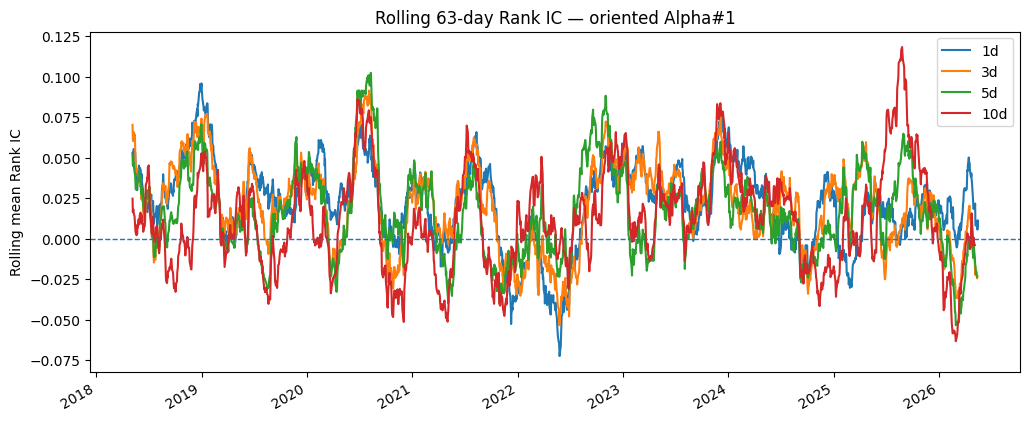

In [12]:
plt.figure(figsize=(12, 5))
for h, series in oriented_rank_ic_by_horizon.items():
    series.rolling(63).mean().plot(label=f"{h}d")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling 63-day Rank IC — oriented Alpha#1")
plt.ylabel("Rolling mean Rank IC")
plt.legend()
plt.show()

## 6. Bucket behavior

This checks whether the **bullish side** of the oriented signal works.

After orientation:

- `top_return` should ideally be higher than `bottom_return`.
- `spread_return = top - bottom` should ideally be positive.

In [13]:
def bucket_returns(signal: pd.DataFrame, future_return: pd.DataFrame, top_n: int) -> pd.DataFrame:
    rows = []
    for date in signal.index.intersection(future_return.index):
        scores = signal.loc[date].dropna()
        rets = future_return.loc[date].dropna()
        common = scores.index.intersection(rets.index)
        if len(common) < top_n * 2:
            continue
        scores = scores[common].sort_values(ascending=False)
        rets = rets[common]
        top_symbols = scores.head(top_n).index
        bottom_symbols = scores.tail(top_n).index
        top_return = rets[top_symbols].mean()
        bottom_return = rets[bottom_symbols].mean()
        rows.append({
            "date": date,
            "top_return": top_return,
            "bottom_return": bottom_return,
            "spread_return": top_return - bottom_return,
            "top_symbols": ",".join(top_symbols),
            "bottom_symbols": ",".join(bottom_symbols),
        })
    return pd.DataFrame(rows).set_index("date")


bucket_rows = []
bucket_frames = {}

for h, fwd in forward_returns.items():
    for top_n in TOP_N_VALUES:
        frame = bucket_returns(oriented_alpha001, fwd, top_n)
        bucket_frames[(h, top_n)] = frame
        bucket_rows.append({
            "horizon_days": h,
            "top_n": top_n,
            "mean_top_return": frame["top_return"].mean(),
            "mean_bottom_return": frame["bottom_return"].mean(),
            "mean_spread_return": frame["spread_return"].mean(),
            "spread_hit_rate": (frame["spread_return"] > 0).mean(),
            "observations": len(frame),
        })

bucket_summary = pd.DataFrame(bucket_rows)
bucket_summary.to_csv(OUTPUT_DIR / "oriented_bucket_returns.csv", index=False)
display(bucket_summary)

,horizon_days,top_n,mean_top_return,mean_bottom_return,mean_spread_return,spread_hit_rate,observations
0,1,5,0.000954,0.000442,0.000512,0.533985,2045
1,1,10,0.000991,0.000534,0.000457,0.522994,2044
2,3,5,0.002765,0.001759,0.001006,0.532061,2043
3,3,10,0.002551,0.001684,0.000866,0.541136,2042
4,5,5,0.004588,0.003515,0.001073,0.528662,2041
5,5,10,0.004279,0.003308,0.000972,0.534804,2040
6,10,5,0.008209,0.007259,0.000949,0.513752,2036
7,10,10,0.008107,0.007214,0.000893,0.517445,2035


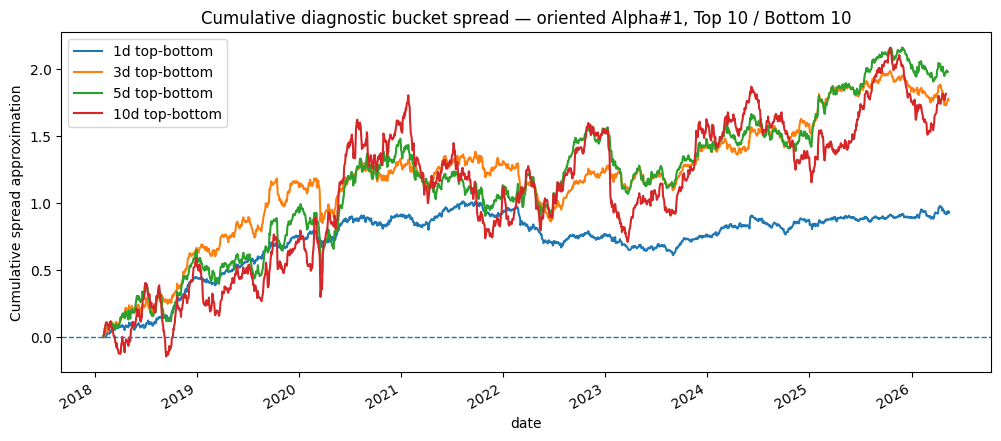

In [14]:
plt.figure(figsize=(12, 5))
for h in FORWARD_HORIZONS:
    frame = bucket_frames[(h, 10)]
    # Multi-day horizons overlap. This is a diagnostic spread chart, not exact PnL.
    frame["spread_return"].fillna(0).cumsum().plot(label=f"{h}d top-bottom")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cumulative diagnostic bucket spread — oriented Alpha#1, Top 10 / Bottom 10")
plt.ylabel("Cumulative spread approximation")
plt.legend()
plt.show()

## 7. Daily basket backtest

This is still a first-pass simulator.

Assumption:

- signal is computed after today's close,
- position earns next trading day's close-to-close return,
- baskets are rebalanced daily,
- transaction cost is approximated using weight turnover.

We test both long-only and long/short variants using the **oriented** signal.

In [15]:
next_day_returns = return_price.pct_change().shift(-1)


def build_weights(signal: pd.DataFrame, top_n: int, long_short: bool) -> pd.DataFrame:
    weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    for date in signal.index:
        scores = signal.loc[date].dropna().sort_values(ascending=False)
        required = top_n * (2 if long_short else 1)
        if len(scores) < required:
            continue
        top = scores.head(top_n).index
        weights.loc[date, top] = 1.0 / top_n
        if long_short:
            bottom = scores.tail(top_n).index
            weights.loc[date, bottom] = -1.0 / top_n
    return weights


def backtest_daily_strategy(
    signal: pd.DataFrame,
    next_returns: pd.DataFrame,
    top_n: int,
    long_short: bool,
    cost_bps: float,
) -> tuple[pd.Series, pd.Series]:
    weights = build_weights(signal, top_n=top_n, long_short=long_short)
    aligned_returns = next_returns.reindex_like(weights)
    gross = (weights * aligned_returns).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    costs = turnover * (cost_bps / 10000.0)
    net = gross - costs
    return net.dropna(), turnover.reindex(net.index).fillna(0)


def performance_metrics(returns: pd.Series, turnover: pd.Series | None = None, periods_per_year: int = 252) -> dict:
    returns = returns.dropna()
    if returns.empty:
        return {}
    equity = (1.0 + returns).cumprod()
    years = len(returns) / periods_per_year
    total_return = equity.iloc[-1] - 1.0
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 and equity.iloc[-1] > 0 else np.nan
    vol = returns.std() * math.sqrt(periods_per_year)
    sharpe = (returns.mean() * periods_per_year) / vol if vol and vol > 0 else np.nan
    downside = returns[returns < 0].std() * math.sqrt(periods_per_year)
    sortino = (returns.mean() * periods_per_year) / downside if downside and downside > 0 else np.nan
    drawdown = equity / equity.cummax() - 1.0
    return {
        "observations": len(returns),
        "total_return": total_return,
        "cagr": cagr,
        "annual_vol": vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": drawdown.min(),
        "daily_win_rate": (returns > 0).mean(),
        "mean_daily_return": returns.mean(),
        "avg_daily_turnover": turnover.mean() if turnover is not None else np.nan,
    }


strategy_returns = {}
turnovers = {}
metric_rows = []

for top_n in TOP_N_VALUES:
    for long_short in [False, True]:
        name = f"{'long_short' if long_short else 'long_only'}_top{top_n}"
        rets, turnover = backtest_daily_strategy(
            oriented_alpha001,
            next_day_returns,
            top_n=top_n,
            long_short=long_short,
            cost_bps=ROUND_TRIP_COST_BPS,
        )
        strategy_returns[name] = rets
        turnovers[name] = turnover
        row = {
            "strategy": name,
            "top_n": top_n,
            "long_short": long_short,
            "signal_orientation": orientation_label,
            "cost_bps": ROUND_TRIP_COST_BPS,
        }
        row.update(performance_metrics(rets, turnover))
        metric_rows.append(row)

strategy_metrics = pd.DataFrame(metric_rows).set_index("strategy")
strategy_metrics.to_csv(OUTPUT_DIR / "oriented_strategy_metrics.csv")
display(strategy_metrics)

,top_n,long_short,signal_orientation,cost_bps,observations,total_return,cagr,annual_vol,sharpe,sortino,max_drawdown,daily_win_rate,mean_daily_return,avg_daily_turnover
strategy,,,,,,,,,,,,,,
long_only_top5,5,False,inverted,10.0,2068,-0.731816,-0.148174,0.208972,-0.662460,-0.884395,-0.744674,0.490329,-0.000549,1.492940
long_short_top5,5,True,inverted,10.0,2068,-0.990712,-0.434573,0.181902,-3.039831,-4.305381,-0.990738,0.408124,-0.002194,2.700774
long_only_top10,10,False,inverted,10.0,2068,-0.402787,-0.060883,0.190773,-0.233382,-0.301349,-0.563827,0.506770,-0.000177,1.144197
long_short_top10,10,True,inverted,10.0,2068,-0.975212,-0.362725,0.137363,-3.208310,-4.467463,-0.975531,0.411025,-0.001749,2.200097


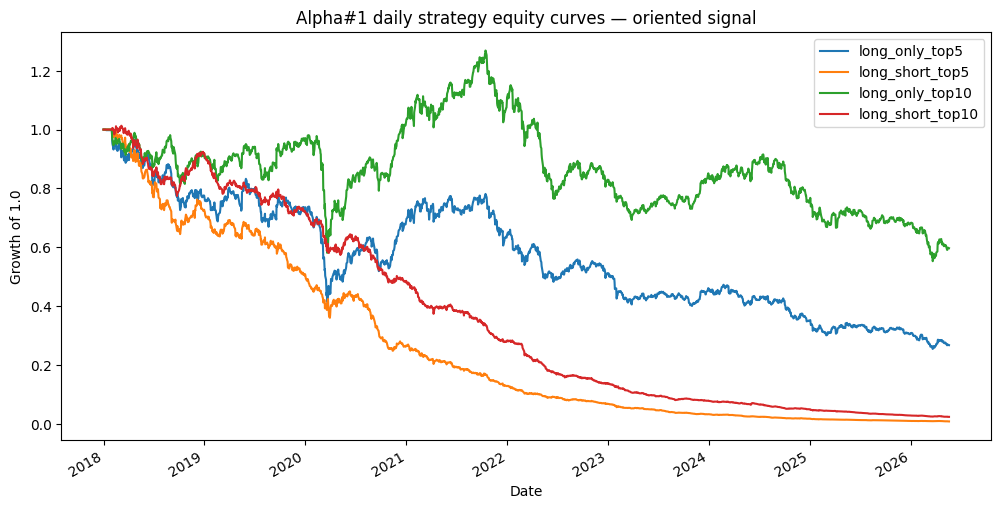

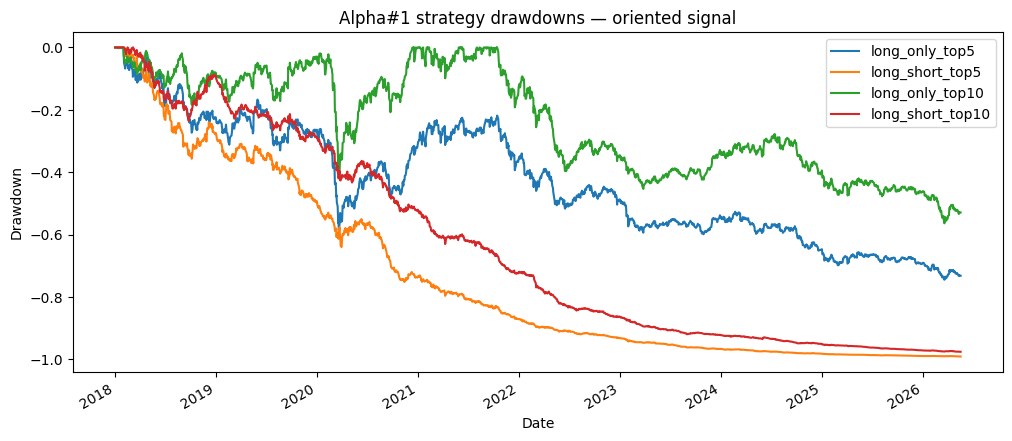

In [16]:
plt.figure(figsize=(12, 6))
for name, rets in strategy_returns.items():
    (1 + rets.fillna(0)).cumprod().plot(label=name)
plt.title("Alpha#1 daily strategy equity curves — oriented signal")
plt.ylabel("Growth of 1.0")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for name, rets in strategy_returns.items():
    equity = (1 + rets.fillna(0)).cumprod()
    drawdown = equity / equity.cummax() - 1
    drawdown.plot(label=name)
plt.title("Alpha#1 strategy drawdowns — oriented signal")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

## 8. Regime analysis

Now we ask:

- Does Alpha#1 work better in bull, bear, or sideways NIFTY regimes?
- Does it work better in low, medium, or high volatility?
- Are failures concentrated in certain environments?

In [17]:
nifty_raw = yf.download(
    NIFTY_INDEX_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
)

if isinstance(nifty_raw.columns, pd.MultiIndex):
    # yfinance sometimes returns ticker-field or field-ticker order depending on version/call.
    if (NIFTY_INDEX_TICKER, "Close") in nifty_raw.columns:
        nifty_close = nifty_raw[(NIFTY_INDEX_TICKER, "Close")]
    elif ("Close", NIFTY_INDEX_TICKER) in nifty_raw.columns:
        nifty_close = nifty_raw[("Close", NIFTY_INDEX_TICKER)]
    else:
        close_cols = [col for col in nifty_raw.columns if "Close" in col]
        nifty_close = nifty_raw[close_cols[0]]
else:
    nifty_close = nifty_raw["Close"]

nifty_close = nifty_close.reindex(return_price.index).ffill()

sma50 = nifty_close.rolling(50).mean()
sma200 = nifty_close.rolling(200).mean()
nifty_ret = nifty_close.pct_change()
nifty_vol20 = nifty_ret.rolling(20).std() * np.sqrt(252)

trend_regime = pd.Series("sideways", index=nifty_close.index)
trend_regime[(nifty_close > sma50) & (sma50 > sma200)] = "bull"
trend_regime[(nifty_close < sma50) & (sma50 < sma200)] = "bear"

vol_q1 = nifty_vol20.quantile(0.33)
vol_q2 = nifty_vol20.quantile(0.66)
vol_regime = pd.Series("medium_vol", index=nifty_close.index)
vol_regime[nifty_vol20 <= vol_q1] = "low_vol"
vol_regime[nifty_vol20 >= vol_q2] = "high_vol"

regimes = pd.DataFrame({
    "nifty_close": nifty_close,
    "trend_regime": trend_regime,
    "nifty_vol20": nifty_vol20,
    "vol_regime": vol_regime,
})

display(regimes.tail())
display(regimes[["trend_regime", "vol_regime"]].value_counts().to_frame("days"))

/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


,nifty_close,trend_regime,nifty_vol20,vol_regime
Date,,,,
2026-05-12,23379.550781,bear,0.146467,medium_vol
2026-05-13,23412.599609,bear,0.132048,medium_vol
2026-05-14,23689.599609,bear,0.140506,medium_vol
2026-05-15,23643.500000,bear,0.137695,medium_vol
2026-05-18,23649.949219,bear,0.137662,medium_vol


days
trend_regime vol_regime      
bull         low_vol      447
sideways     medium_vol   398
             high_vol     341
bull         medium_vol   243
sideways     low_vol      220
bull         high_vol     219
bear         high_vol     136
             medium_vol    55
             low_vol        9

In [18]:
rank_ic_default = oriented_rank_ic_by_horizon[DEFAULT_HORIZON].rename("rank_ic")
regime_ic = pd.concat([rank_ic_default, regimes[["trend_regime", "vol_regime"]]], axis=1).dropna()

regime_rows = []

for regime_col in ["trend_regime", "vol_regime"]:
    grouped = regime_ic.groupby(regime_col)["rank_ic"]
    for regime_name, values in grouped:
        regime_rows.append({
            "section": "ic",
            "regime_type": regime_col,
            "regime": regime_name,
            "mean_rank_ic": values.mean(),
            "rank_icir": values.mean() / values.std() if values.std() else np.nan,
            "positive_rate": (values > 0).mean(),
            "observations": len(values),
            "mean_strategy_return": np.nan,
            "strategy_sharpe": np.nan,
        })

default_strategy_name = "long_only_top10" if "long_only_top10" in strategy_returns else list(strategy_returns)[0]
default_strategy = strategy_returns[default_strategy_name].rename("strategy_return")
strat_regime = pd.concat([default_strategy, regimes[["trend_regime", "vol_regime"]]], axis=1).dropna()

for regime_col in ["trend_regime", "vol_regime"]:
    grouped = strat_regime.groupby(regime_col)["strategy_return"]
    for regime_name, values in grouped:
        regime_rows.append({
            "section": f"strategy:{default_strategy_name}",
            "regime_type": regime_col,
            "regime": regime_name,
            "mean_rank_ic": np.nan,
            "rank_icir": np.nan,
            "positive_rate": (values > 0).mean(),
            "observations": len(values),
            "mean_strategy_return": values.mean(),
            "strategy_sharpe": (values.mean() * 252) / (values.std() * np.sqrt(252)) if values.std() else np.nan,
        })

regime_report = pd.DataFrame(regime_rows)
regime_report.to_csv(OUTPUT_DIR / "oriented_regime_report.csv", index=False)
display(regime_report)

,section,regime_type,regime,mean_rank_ic,rank_icir,positive_rate,observations,mean_strategy_return,strategy_sharpe
0,ic,trend_regime,bear,0.033472,0.180186,0.558974,195,NaN,NaN
1,ic,trend_regime,bull,0.013058,0.073399,0.531353,909,NaN,NaN
2,ic,trend_regime,sideways,0.017136,0.098889,0.531483,937,NaN,NaN
3,ic,vol_regime,high_vol,0.025797,0.138397,0.541667,696,NaN,NaN
4,ic,vol_regime,low_vol,0.016889,0.100443,0.545185,675,NaN,NaN
5,ic,vol_regime,medium_vol,0.007610,0.043696,0.514925,670,NaN,NaN
6,strategy:long_only_top10,trend_regime,bear,NaN,NaN,0.540000,200,0.001207,1.003823
7,strategy:long_only_top10,trend_regime,bull,NaN,NaN,0.504950,909,-0.000230,-0.399308
8,strategy:long_only_top10,trend_regime,sideways,NaN,NaN,0.501564,959,-0.000415,-0.526766
9,strategy:long_only_top10,vol_regime,high_vol,NaN,NaN,0.541667,696,0.000535,0.534962


## 9. Stock-level ranking

We rank stocks by how compatible they are with the **oriented** Alpha#1.

This is not proof. It is a shortlist for deeper review.

Useful signs:

- positive alpha/future-return correlation,
- good returns when selected in top bucket,
- positive hit rate when selected,
- enough selection observations,
- bottom bucket is weak or avoidable.

In [19]:
def stock_level_alpha_report(
    signal: pd.DataFrame,
    future_return: pd.DataFrame,
    top_n: int = 10,
) -> pd.DataFrame:
    rows = []
    top_mask = pd.DataFrame(False, index=signal.index, columns=signal.columns)
    bottom_mask = pd.DataFrame(False, index=signal.index, columns=signal.columns)

    for date in signal.index:
        scores = signal.loc[date].dropna().sort_values(ascending=False)
        if len(scores) < top_n * 2:
            continue
        top_mask.loc[date, scores.head(top_n).index] = True
        bottom_mask.loc[date, scores.tail(top_n).index] = True

    for symbol in signal.columns:
        pair = pd.concat(
            [signal[symbol].rename("oriented_alpha"), future_return[symbol].rename("fwd")],
            axis=1,
        ).dropna()

        top_rets = future_return[symbol][top_mask[symbol]].dropna()
        bottom_rets = future_return[symbol][bottom_mask[symbol]].dropna()

        rows.append({
            "symbol": symbol,
            "alpha_fwd_corr": pair["oriented_alpha"].corr(pair["fwd"], method="spearman") if len(pair) >= 30 else np.nan,
            "top_selected_mean_fwd_return": top_rets.mean(),
            "top_selected_hit_rate": (top_rets > 0).mean() if len(top_rets) else np.nan,
            "top_selected_count": len(top_rets),
            "bottom_selected_mean_fwd_return": bottom_rets.mean(),
            "bottom_selected_hit_rate": (bottom_rets > 0).mean() if len(bottom_rets) else np.nan,
            "bottom_selected_count": len(bottom_rets),
        })

    report = pd.DataFrame(rows).set_index("symbol")

    components = pd.DataFrame(index=report.index)
    components["corr"] = report["alpha_fwd_corr"].rank(pct=True)
    components["top_return"] = report["top_selected_mean_fwd_return"].rank(pct=True)
    components["top_hit"] = report["top_selected_hit_rate"].rank(pct=True)
    components["avoid_bottom"] = (-report["bottom_selected_mean_fwd_return"]).rank(pct=True)
    components["sample"] = report["top_selected_count"].rank(pct=True)

    report["alpha001_stock_score"] = (
        0.30 * components["corr"]
        + 0.30 * components["top_return"]
        + 0.20 * components["top_hit"]
        + 0.10 * components["avoid_bottom"]
        + 0.10 * components["sample"]
    )

    return report.sort_values("alpha001_stock_score", ascending=False)


stock_ranking = stock_level_alpha_report(
    oriented_alpha001,
    forward_returns[DEFAULT_HORIZON],
    top_n=10,
)

stock_ranking.to_csv(OUTPUT_DIR / "oriented_stock_ranking.csv")
display(stock_ranking.head(15))
display(stock_ranking.tail(15))

,alpha_fwd_corr,top_selected_mean_fwd_return,top_selected_hit_rate,top_selected_count,bottom_selected_mean_fwd_return,bottom_selected_hit_rate,bottom_selected_count,alpha001_stock_score
symbol,,,,,,,,
APOLLOHOSP,0.073012,0.008605,0.594000,500,0.001322,0.515625,192,0.917391
DRREDDY,0.070465,0.006479,0.608229,559,0.002537,0.475936,187,0.884783
RELIANCE,0.080625,0.007898,0.601064,376,-0.000370,0.494536,732,0.884783
JSWSTEEL,0.060317,0.008506,0.602469,405,0.002390,0.538905,347,0.843478
SBILIFE,0.063383,0.005884,0.567089,395,0.001487,0.531250,736,0.778261
BHARTIARTL,0.030013,0.007404,0.563433,536,0.003169,0.530864,162,0.769565
GRASIM,0.047796,0.006440,0.594249,313,0.001517,0.495114,307,0.756522
ICICIBANK,0.021067,0.008661,0.586301,365,0.001937,0.511222,401,0.741304
TATASTEEL,0.054046,0.006841,0.554896,337,0.002208,0.515544,772,0.730435


,alpha_fwd_corr,top_selected_mean_fwd_return,top_selected_hit_rate,top_selected_count,bottom_selected_mean_fwd_return,bottom_selected_hit_rate,bottom_selected_count,alpha001_stock_score
symbol,,,,,,,,
TRENT,0.015450,0.003076,0.542700,363,0.007719,0.567430,786,0.381522
BAJAJ-AUTO,-0.005752,0.003610,0.535070,499,0.004043,0.546875,192,0.367391
BAJAJFINSV,0.004821,0.000766,0.549348,537,0.010410,0.593750,96,0.355435
HINDUNILVR,0.011415,0.002145,0.504292,466,0.002003,0.482906,468,0.347826
ULTRACEMCO,0.000912,0.004018,0.528875,329,0.004197,0.526810,746,0.328261
INFY,-0.005013,0.000856,0.532751,458,0.002225,0.541741,563,0.284783
ADANIPORTS,-0.027970,0.003499,0.517442,516,0.011040,0.547445,137,0.277174
ADANIENT,-0.061824,0.004843,0.500000,516,0.018886,0.537313,134,0.275000
SBIN,-0.020047,0.002146,0.547904,334,0.006594,0.562338,770,0.260870


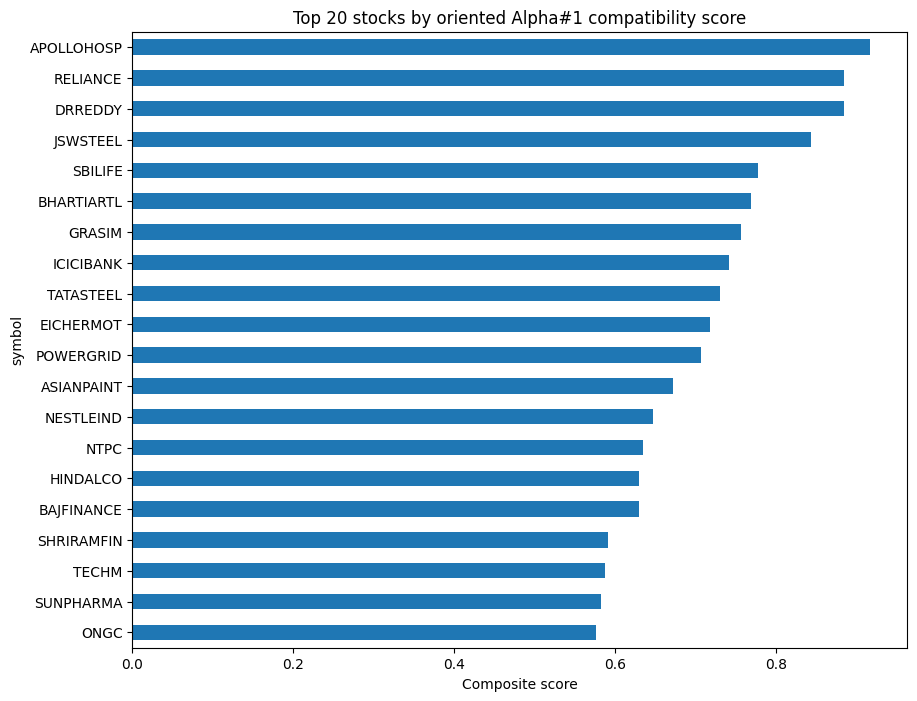

In [20]:
plt.figure(figsize=(10, 8))
stock_ranking["alpha001_stock_score"].head(20).sort_values().plot(kind="barh")
plt.title("Top 20 stocks by oriented Alpha#1 compatibility score")
plt.xlabel("Composite score")
plt.show()

## 10. Latest candidate table

This produces **candidate ideas**, not trades.

A candidate requires:

- top bucket on the oriented signal,
- recent Rank IC support,
- stock-level compatibility,
- regime support.

If the raw Alpha#1 was inverted, candidates will come from the **raw bottom bucket** because that became the oriented top bucket.

In [21]:
def minmax_score(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    lo, hi = series.min(), series.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(0.5, index=series.index)
    return (series - lo) / (hi - lo)


latest_date = oriented_alpha001.dropna(how="all").index[-1]
latest_scores = oriented_alpha001.loc[latest_date].dropna().sort_values(ascending=False)
latest_top = latest_scores.head(10)

recent_ic = oriented_rank_ic_by_horizon[DEFAULT_HORIZON].loc[:latest_date].tail(63)
recent_ic_score = float(np.clip((recent_ic.mean() + 0.05) / 0.10, 0, 1)) if len(recent_ic) else 0.5

current_trend = regimes.loc[latest_date, "trend_regime"]
current_vol = regimes.loc[latest_date, "vol_regime"]

regime_ic_lookup = regime_report[
    (regime_report["section"] == "ic")
].set_index(["regime_type", "regime"])

trend_score_raw = regime_ic_lookup.loc[("trend_regime", current_trend), "mean_rank_ic"] if ("trend_regime", current_trend) in regime_ic_lookup.index else 0
vol_score_raw = regime_ic_lookup.loc[("vol_regime", current_vol), "mean_rank_ic"] if ("vol_regime", current_vol) in regime_ic_lookup.index else 0
regime_score = float(np.clip(((trend_score_raw + vol_score_raw) / 2 + 0.05) / 0.10, 0, 1))

stock_score_scaled = minmax_score(stock_ranking["alpha001_stock_score"])

candidate_rows = []
for symbol, oriented_score in latest_top.items():
    raw_score = raw_alpha001.loc[latest_date, symbol]
    candidate_rows.append({
        "date": latest_date,
        "symbol": symbol,
        "alpha": "alpha001",
        "raw_alpha001_score": raw_score,
        "oriented_signal_score": oriented_score,
        "signal_orientation": orientation_label,
        "suggested_direction": "long",
        "horizon_days": DEFAULT_HORIZON,
        "recent_ic_score": recent_ic_score,
        "regime_score": regime_score,
        "stock_score": stock_score_scaled.get(symbol, 0.5),
        "confidence_v0": (
            0.35 * recent_ic_score
            + 0.30 * stock_score_scaled.get(symbol, 0.5)
            + 0.25 * regime_score
            + 0.10 * float(oriented_score > 0)
        ),
        "reason": (
            f"Top oriented Alpha#1 bucket; orientation={orientation_label}; "
            f"trend={current_trend}; volatility={current_vol}; "
            f"recent {DEFAULT_HORIZON}d IC mean={recent_ic.mean():.4f}"
        ),
    })

latest_candidates = pd.DataFrame(candidate_rows).sort_values("confidence_v0", ascending=False)
latest_candidates.to_csv(OUTPUT_DIR / "latest_trade_candidates_oriented.csv", index=False)
display(latest_candidates)

,date,symbol,alpha,raw_alpha001_score,oriented_signal_score,signal_orientation,suggested_direction,horizon_days,recent_ic_score,regime_score,stock_score,confidence_v0,reason
3,2026-05-18,APOLLOHOSP,alpha001,-0.217391,0.217391,inverted,long,5,0.266203,0.705408,1.000000,0.669523,Top oriented Alpha#1 bucket; orientation=inver...
7,2026-05-18,JSWSTEEL,alpha001,-0.217391,0.217391,inverted,long,5,0.266203,0.705408,0.903683,0.640628,Top oriented Alpha#1 bucket; orientation=inver...
1,2026-05-18,GRASIM,alpha001,-0.445652,0.445652,inverted,long,5,0.266203,0.705408,0.790368,0.606634,Top oriented Alpha#1 bucket; orientation=inver...
5,2026-05-18,ASIANPAINT,alpha001,-0.217391,0.217391,inverted,long,5,0.266203,0.705408,0.679887,0.573489,Top oriented Alpha#1 bucket; orientation=inver...
2,2026-05-18,NESTLEIND,alpha001,-0.445652,0.445652,inverted,long,5,0.266203,0.705408,0.648725,0.564141,Top oriented Alpha#1 bucket; orientation=inver...
8,2026-05-18,M&M,alpha001,-0.217391,0.217391,inverted,long,5,0.266203,0.705408,0.519830,0.525472,Top oriented Alpha#1 bucket; orientation=inver...
6,2026-05-18,HDFCLIFE,alpha001,-0.217391,0.217391,inverted,long,5,0.266203,0.705408,0.457507,0.506775,Top oriented Alpha#1 bucket; orientation=inver...
0,2026-05-18,AXISBANK,alpha001,-0.478261,0.478261,inverted,long,5,0.266203,0.705408,0.402266,0.490203,Top oriented Alpha#1 bucket; orientation=inver...
9,2026-05-18,LT,alpha001,-0.217391,0.217391,inverted,long,5,0.266203,0.705408,0.379603,0.483404,Top oriented Alpha#1 bucket; orientation=inver...
4,2026-05-18,BAJAJ-AUTO,alpha001,-0.217391,0.217391,inverted,long,5,0.266203,0.705408,0.283286,0.454509,Top oriented Alpha#1 bucket; orientation=inver...


## 11. What to do next

Use this notebook to decide whether Alpha#1 deserves promotion from exploratory research to a deterministic project signal.

Minimum promotion questions:

1. Is oriented Rank IC positive and stable?
2. Does top-minus-bottom spread survive transaction costs?
3. Does long-only work, or only long/short?
4. Is performance concentrated in just a few stocks?
5. Is performance concentrated in one market regime?
6. Does the signal survive different start dates?
7. Does it survive excluding the top 3 best stocks?
8. Does it survive stricter data-quality filters?
9. Does it survive a realistic execution assumption?
10. Is the direction stable, or does it keep flipping?

Suggested next code locations after validation:

```text
research/notebooks/nifty50_alpha001_guided_research_v2.ipynb
research/artifacts/alpha001_nifty50/

project/signals/alpha001.py
project/research/alpha001_config.yaml
tests/test_alpha001.py
```

Important lesson from this pass:

> The raw formula is the research object. The oriented signal is the tradable object.